# ISOT Fake News Dataset 



## 1. EDA

This notebook focuses on a detailed exploratory data analysis (EDA) of the ISOT Fake News dataset.
Goals:
- Understand dataset structure and class balance.
- Inspect missing values and duplicates.
- Explore text length distributions and vocabulary patterns.
- Review sample records.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=sns.color_palette("Set2"))

In [2]:
true_df = pd.read_csv(r"C:/Users/pro/Downloads/fake_news_isot_project/.csv")
fake_df = pd.read_csv(r"C:/Users/pro/Downloads/fake_news_isot_project/data.csv")

true_df['label'] = 'real'
fake_df['label'] = 'fake'

df = pd.concat([true_df, fake_df], ignore_index=True)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/pro/Downloads/fake_news_isot_project/data.csv'

## Dataset overview
We check the shape, column names, and a quick preview.

In [ ]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.sample(5, random_state=42)

## Data types and missing values

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  str  
dtypes: str(5)
memory usage: 1.7 MB


In [ ]:
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

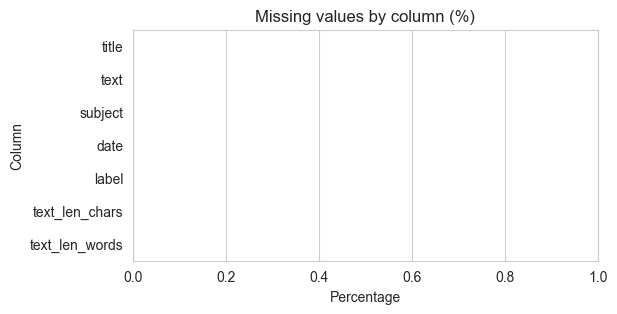

In [14]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title('Missing values by column (%)')
plt.xlabel('Percentage')
plt.ylabel('Column')
plt.xlim(0, max(1, missing_pct.max()))
plt.show()

**Interprétation.** Ce graphe montre le pourcentage de valeurs manquantes par colonne.
Si toutes les barres sont proches de 0, les données sont complètes.
Des valeurs élevées indiqueraient des colonnes à nettoyer ou à éliminer.

## Duplicates

In [2]:
duplicates = df.duplicated().sum()
print('Number of duplicates:', duplicates)

NameError: name 'df' is not defined

## Class balance

label
fake    23481
real    21417
Name: count, dtype: int64


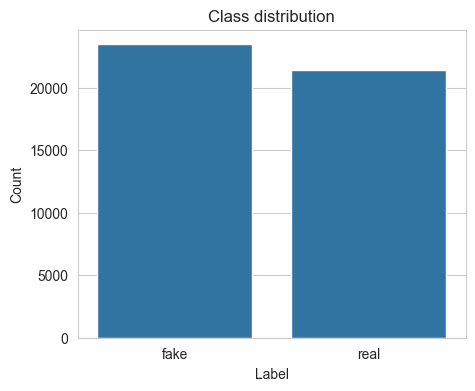

In [23]:
class_counts = df['label'].value_counts()
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

**Interprétation.** La barre indique le nombre d’articles par classe.
On vérifie ici si le dataset est équilibré ou non.
Un déséquilibre fort nécessite des précautions lors de l’entraînement.

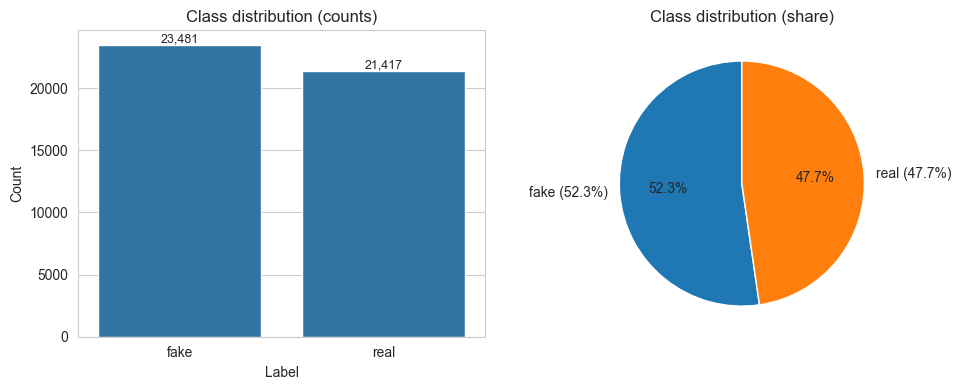

In [15]:
class_counts_pct = (class_counts / class_counts.sum() * 100).round(2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set_title('Class distribution (counts)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
axes[1].pie(
    class_counts.values,
    labels=[f"{lbl} ({pct}%)" for lbl, pct in zip(class_counts.index, class_counts_pct)],
    autopct='%1.1f%%',
    startangle=90
 )
axes[1].set_title('Class distribution (share)')
plt.tight_layout()
plt.show()

**Interprétation.** Le camembert met en évidence la part relative de chaque classe.
Une répartition proche de 50/50 est idéale pour les modèles.
Si une classe domine, on peut prévoir un rééquilibrage.

## Subject distribution
Cette section analyse les thèmes (colonne subject) et leur répartition par classe.

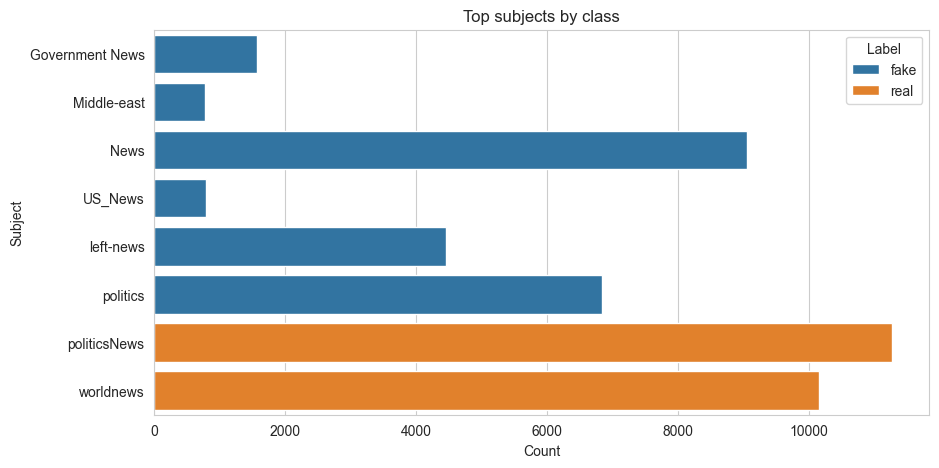

In [18]:
if 'subject' in df.columns:
    subject_counts = (
        df.groupby(['label', 'subject'])
        .size()
        .reset_index(name='count')
    )
    top_subjects = (
        subject_counts.groupby('subject')['count']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    subject_counts = subject_counts[subject_counts['subject'].isin(top_subjects)]
    plt.figure(figsize=(10, 5))
    sns.barplot(data=subject_counts, x='count', y='subject', hue='label')
    plt.title('Top subjects by class')
    plt.xlabel('Count')
    plt.ylabel('Subject')
    plt.legend(title='Label')
    plt.show()
else:
    print('Column subject not found in dataset.')

**Interprétation.** Ce graphe compare les sujets dominants entre fake et real.
Il permet d’identifier des thèmes sur‑représentés dans une classe.
Les sujets très spécifiques peuvent devenir des indicateurs utiles.

## Text length statistics

In [9]:
df['text_len_chars'] = df['text'].astype(str).str.len()
df['text_len_words'] = df['text'].astype(str).str.split().str.len()

df[['text_len_chars', 'text_len_words']].describe()

,text_len_chars,text_len_words
count,44898.000000,44898.000000
mean,2469.109693,405.282284
std,2171.617091,351.265595
min,1.000000,0.000000
25%,1234.000000,203.000000
50%,2186.000000,362.000000
75%,3105.000000,513.000000
max,51794.000000,8135.000000


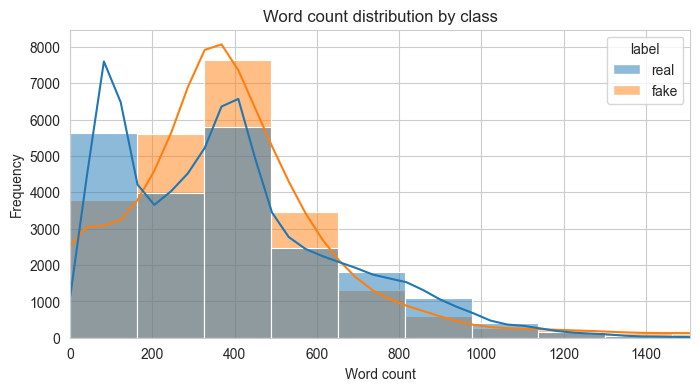

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='text_len_words', hue='label', bins=50, kde=True)
plt.title('Word count distribution by class')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.xlim(0, df['text_len_words'].quantile(0.99))
plt.show()

**Interprétation.** Ce histogramme compare la longueur des articles en mots.
On observe la dispersion et les valeurs extrêmes par classe.
Des différences de distribution peuvent aider la classification.

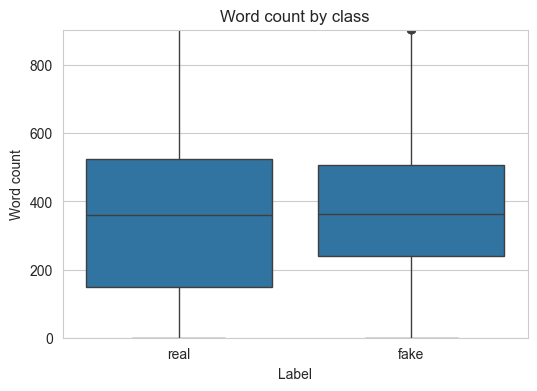

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='label', y='text_len_words')
plt.title('Word count by class')
plt.xlabel('Label')
plt.ylabel('Word count')
plt.ylim(0, df['text_len_words'].quantile(0.95))
plt.show()

**Interprétation.** Le boxplot met en évidence médiane et dispersion par classe.
Des écarts visibles suggèrent des styles d’écriture différents.
Les valeurs extrêmes sont limitées pour éviter l’effet des outliers.

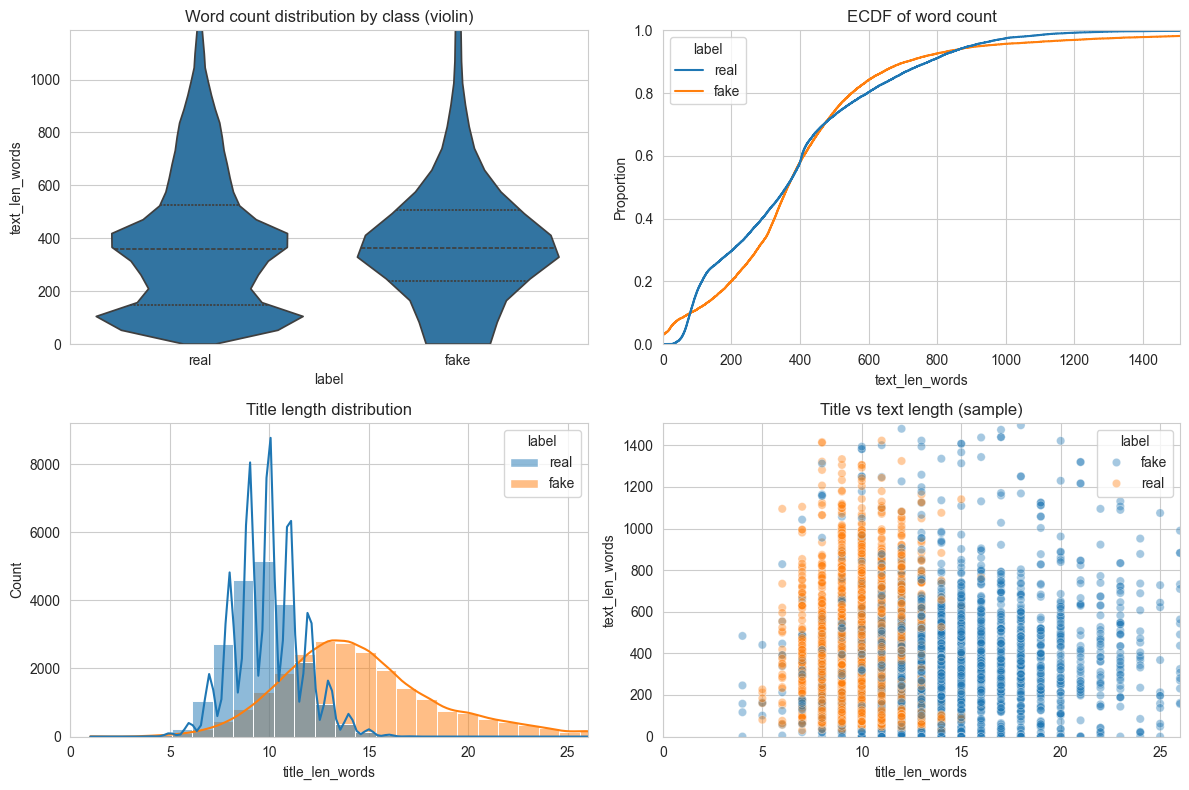

In [16]:
df['title_len_words'] = df['title'].astype(str).str.split().str.len()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.violinplot(data=df, x='label', y='text_len_words', ax=axes[0, 0], inner='quartile', cut=0)
axes[0, 0].set_ylim(0, df['text_len_words'].quantile(0.98))
axes[0, 0].set_title('Word count distribution by class (violin)')
sns.ecdfplot(data=df, x='text_len_words', hue='label', ax=axes[0, 1])
axes[0, 1].set_xlim(0, df['text_len_words'].quantile(0.99))
axes[0, 1].set_title('ECDF of word count')
sns.histplot(data=df, x='title_len_words', hue='label', bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Title length distribution')
axes[1, 0].set_xlim(0, df['title_len_words'].quantile(0.99))
sample_df = df[['title_len_words', 'text_len_words', 'label']].sample(5000, random_state=42)
sns.scatterplot(data=sample_df, x='title_len_words', y='text_len_words', hue='label', alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_ylim(0, df['text_len_words'].quantile(0.99))
axes[1, 1].set_xlim(0, df['title_len_words'].quantile(0.99))
axes[1, 1].set_title('Title vs text length (sample)')
plt.tight_layout()
plt.show()

**Interprétation.** Les violons et ECDF résument la distribution complète des longueurs.
Le graphique des titres montre la taille moyenne des headlines par classe.
Le nuage titre vs texte permet d’observer la relation entre les deux tailles.

## Title length in characters
Cette partie mesure la longueur des titres en caractères par classe.

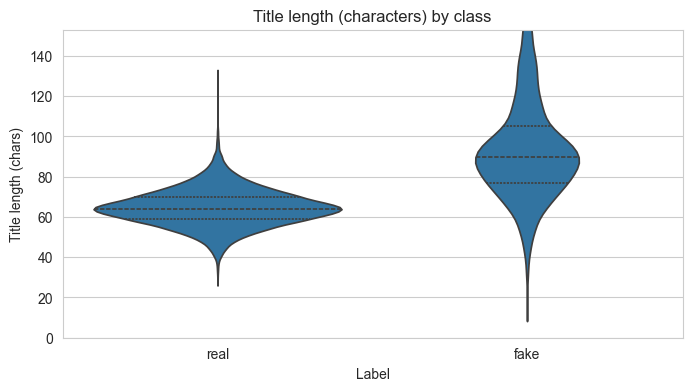

In [19]:
df['title_len_chars'] = df['title'].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='label', y='title_len_chars', inner='quartile', cut=0)
plt.title('Title length (characters) by class')
plt.xlabel('Label')
plt.ylabel('Title length (chars)')
plt.ylim(0, df['title_len_chars'].quantile(0.98))
plt.show()

**Interprétation.** Ce graphe compare la taille des titres en caractères.
Des titres plus courts ou plus longs peuvent être liés au style des articles.
Une différence nette peut aider les modèles basés sur la longueur.

## Unique words vs text length
Cette section compare la richesse lexicale et la longueur des articles.

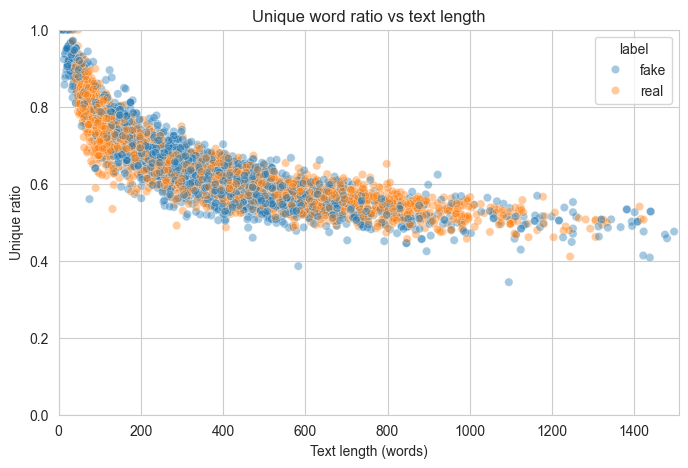

In [20]:
text_tokens = df['text'].astype(str).str.split()
df['unique_words'] = text_tokens.apply(lambda tokens: len(set(tokens)))
df['unique_ratio'] = df['unique_words'] / df['text_len_words'].replace(0, np.nan)
sample_unique = df[['text_len_words', 'unique_ratio', 'label']].sample(5000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_unique, x='text_len_words', y='unique_ratio', hue='label', alpha=0.4)
plt.title('Unique word ratio vs text length')
plt.xlabel('Text length (words)')
plt.ylabel('Unique ratio')
plt.xlim(0, df['text_len_words'].quantile(0.99))
plt.ylim(0, 1)
plt.show()

**Interprétation.** Le ratio de mots uniques mesure la richesse lexicale.
Un ratio plus faible peut indiquer des répétitions ou un vocabulaire limité.
La relation avec la longueur aide à distinguer les styles d’articles.

## Correlation heatmap
Cette carte montre les relations entre métriques numériques et la classe.

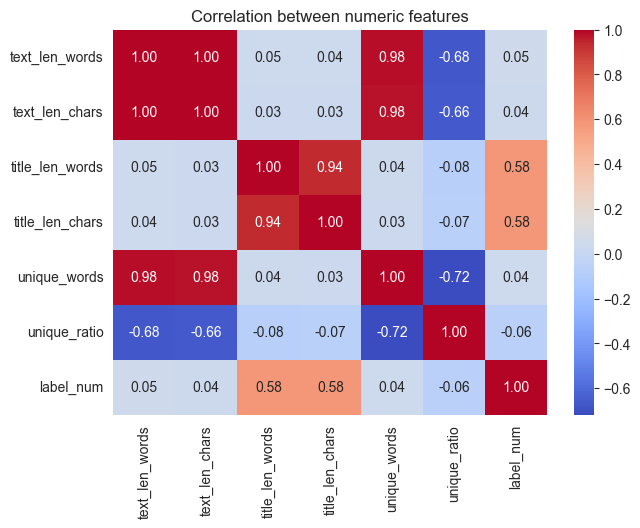

In [21]:
numeric_df = df.copy()
numeric_df['label_num'] = numeric_df['label'].map({'real': 0, 'fake': 1})
corr_cols = [
    'text_len_words',
    'text_len_chars',
    'title_len_words',
    'title_len_chars',
    'unique_words',
    'unique_ratio',
    'label_num'
]
corr_data = numeric_df[corr_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between numeric features')
plt.show()

**Interprétation.** Cette matrice met en évidence les relations entre variables numériques.
Une corrélation élevée indique que deux métriques varient ensemble.
La colonne label_num aide à repérer les features liées à la classe.

## Most frequent words (quick view)

In [12]:
sample_texts = df['text'].astype(str).sample(2000, random_state=42)
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(sample_texts)
word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': np.array(X.sum(axis=0)).flatten()
}).sort_values('count', ascending=False)
word_freq

,word,count
16,trump,6175
12,said,5933
9,president,2652
8,people,1830
13,state,1575
6,new,1437
11,reuters,1321
7,obama,1313
1,clinton,1295
2,donald,1287


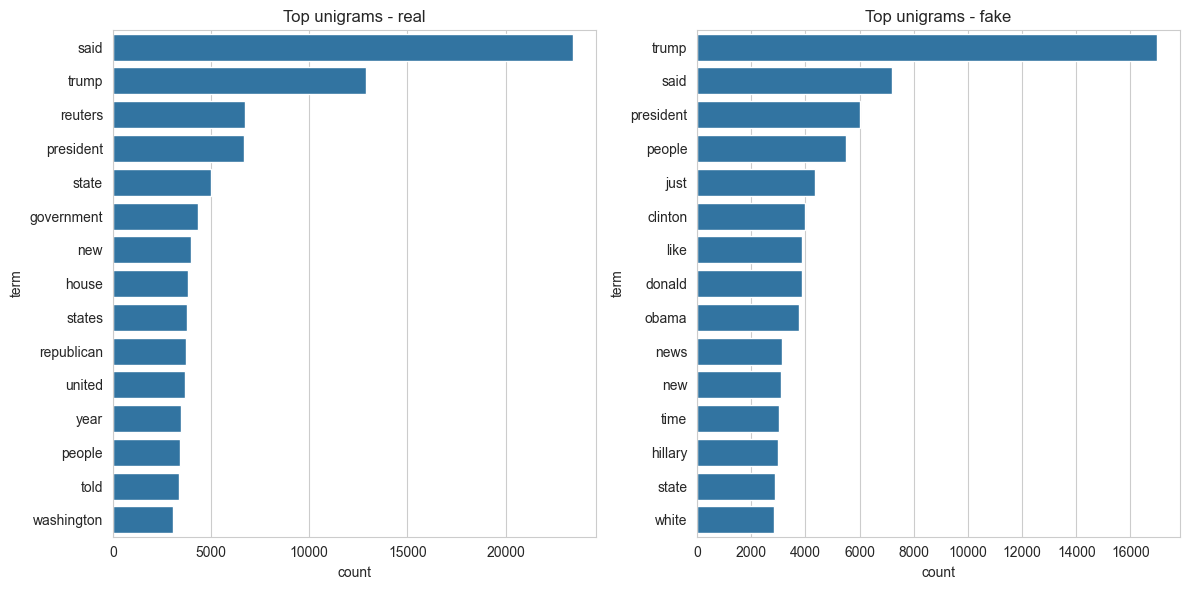

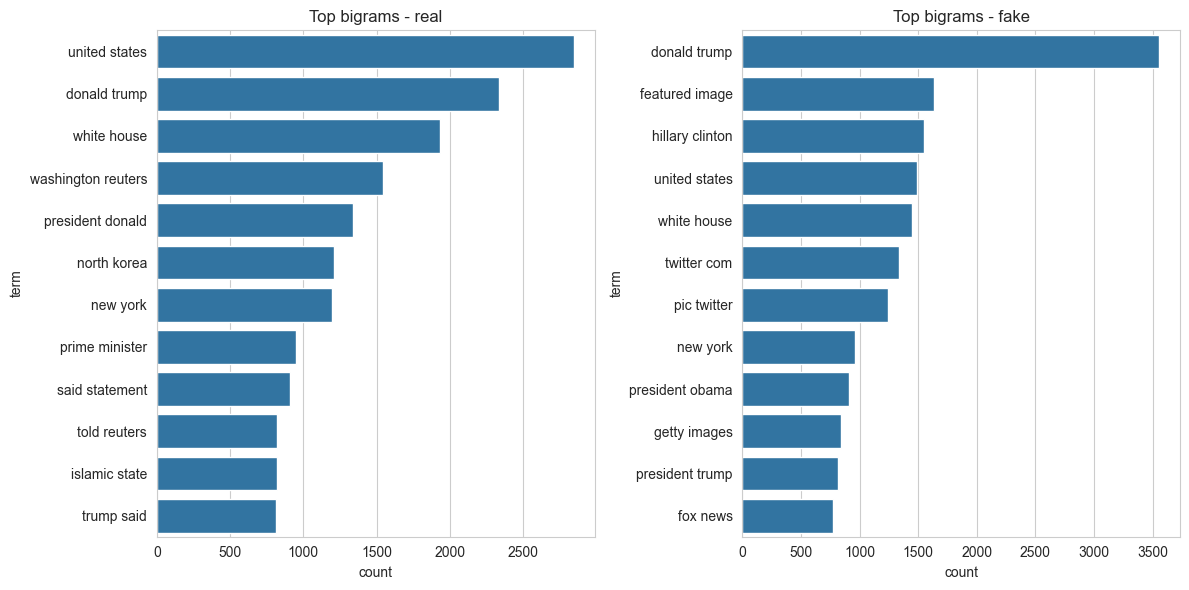

In [17]:
def get_top_terms(texts, ngram_range=(1, 1), top_n=15):
    vec = CountVectorizer(stop_words='english', max_features=5000, ngram_range=ngram_range)
    X = vec.fit_transform(texts)
    sums = np.array(X.sum(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    return (
        pd.DataFrame({'term': terms, 'count': sums})
        .sort_values('count', ascending=False)
        .head(top_n)
    )

sample_real = df[df['label'] == 'real']['text'].astype(str).sample(5000, random_state=42)
sample_fake = df[df['label'] == 'fake']['text'].astype(str).sample(5000, random_state=42)

top_real = get_top_terms(sample_real, ngram_range=(1, 1), top_n=15)
top_fake = get_top_terms(sample_fake, ngram_range=(1, 1), top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real, y='term', x='count', ax=axes[0])
axes[0].set_title('Top unigrams - real')
sns.barplot(data=top_fake, y='term', x='count', ax=axes[1])
axes[1].set_title('Top unigrams - fake')
plt.tight_layout()
plt.show()

top_real_bi = get_top_terms(sample_real, ngram_range=(2, 2), top_n=12)
top_fake_bi = get_top_terms(sample_fake, ngram_range=(2, 2), top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real_bi, y='term', x='count', ax=axes[0])
axes[0].set_title('Top bigrams - real')
sns.barplot(data=top_fake_bi, y='term', x='count', ax=axes[1])
axes[1].set_title('Top bigrams - fake')
plt.tight_layout()
plt.show()

**Interprétation.** Ces barres montrent les termes les plus fréquents par classe.
Les unigrams révèlent le vocabulaire dominant, les bigrams montrent des expressions typiques.
Les différences de termes peuvent guider le choix des features.

## Top trigrams by class
Analyse des expressions fréquentes à 3 mots par classe.

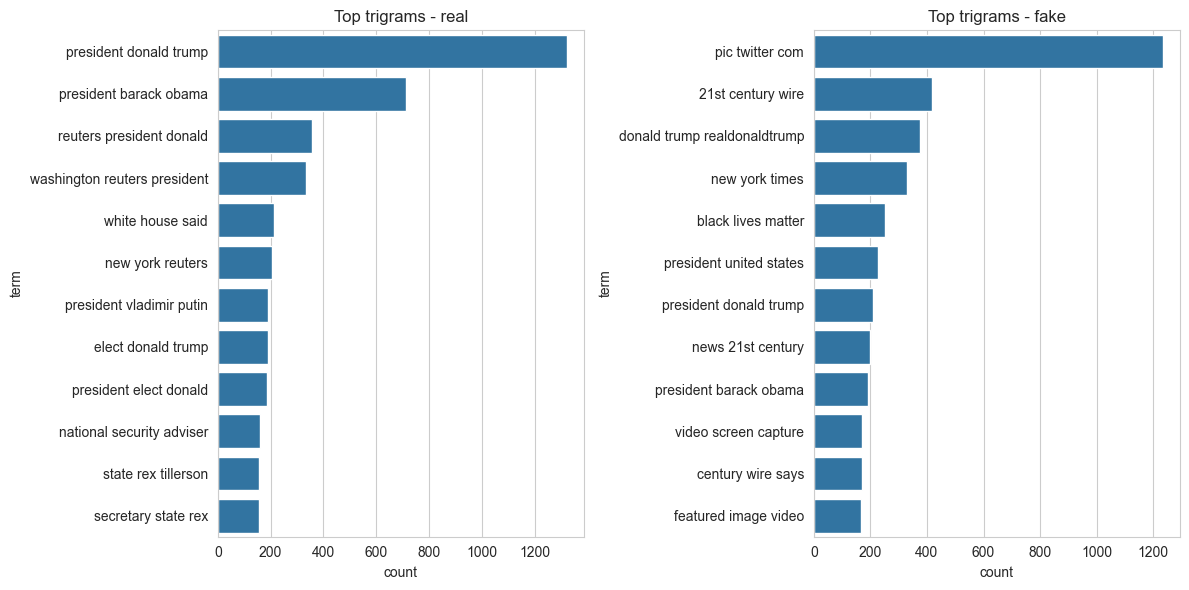

In [22]:
top_real_tri = get_top_terms(sample_real, ngram_range=(3, 3), top_n=12)
top_fake_tri = get_top_terms(sample_fake, ngram_range=(3, 3), top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(data=top_real_tri, y='term', x='count', ax=axes[0])
axes[0].set_title('Top trigrams - real')
sns.barplot(data=top_fake_tri, y='term', x='count', ax=axes[1])
axes[1].set_title('Top trigrams - fake')
plt.tight_layout()
plt.show()

**Interprétation.** Les trigrams révèlent des expressions plus spécifiques.
Ils sont utiles pour capter des tournures ou slogans récurrents.
Des différences nettes peuvent améliorer la séparation des classes.

## Sample records

In [13]:
df[['title', 'text', 'label']].sample(3, random_state=7)

,title,text,label
25168,Woman Reveals How Head Of Fox News Molested H...,The parent company for the conservative Fox Ne...,fake
5096,Revised U.S. travel ban will still curtail tou...,BERLIN (Reuters) - U.S. President Donald Trump...,real
3123,India's Modi could discuss visa issue with Tru...,NEW DELHI (Reuters) - India could take up the ...,real


4. Preprocessement NLP

Étapes :

Suppression des doublons et NaN
Normalisation (minuscules, URLs, HTML, ponctuation)
Tokenisation
Filtrage stopwords + tokens trop courts
Lemmatisation guidée par POS tags
Reconstruction du texte



In [ ]:
# ── Nettoyage structurel ──────────────────────────────────────────────────────
df = df_raw.copy()

n_avant = len(df)
df.drop_duplicates(subset="statement", inplace=True)
df.dropna(subset=["statement", "label"], inplace=True)
df = df[df["word_count"] >= 5].copy()   # retirer textes quasi-vides
df.reset_index(drop=True, inplace=True)

print(f"Lignes avant nettoyage structurel : {n_avant}")
print(f"Lignes après nettoyage structurel : {len(df)}")
print(f"Supprimées : {n_avant - len(df)}") 